In [1]:
from pathlib import Path
from mhdr.dataloader.process_multilabel_human_data import load_multilabel_human_data
from mhdr.dataloader.io import read_csv
import pandas as pd
from itertools import product
import os
INPUT_DIR = Path.cwd() / "input"
OUTPUT_DIR = Path.cwd() / "output"
TEMP_DIR = Path.cwd() / "temp"
DATA = read_csv(INPUT_DIR / "questions_master.csv")
DIMENSIONS = [
    "Emotional",
    "Environmental",
    "Financial",
    "Intellectual",
    "Occupational",
    "Physical",
    "Social",
    "Spiritual",
]

In [2]:
HUMAN_DATA = load_multilabel_human_data(INPUT_DIR, [DATA])
print(len(HUMAN_DATA))
HUMAN_DATA.head()

3480


,qid,text,Emotional,Environmental,Financial,Intellectual,Occupational,Physical,Social,Spiritual
0,CD_RISC_1,I am able to adapt when changes occur.,2,0,0,1,0,0,0,0
1,CD_RISC_1,I am able to adapt when changes occur.,3,0,0,1,0,0,0,2
2,CD_RISC_1,I am able to adapt when changes occur.,1,0,0,0,0,0,3,2
3,CD_RISC_1,I am able to adapt when changes occur.,3,1,0,0,0,0,0,2
4,CD_RISC_1,I am able to adapt when changes occur.,0,3,0,1,0,0,2,0


In [3]:
from sklearn.model_selection import train_test_split
import tempfile
from pathlib import Path


def split_by_qid(df):

    qids = df["qid"].unique()

    train_qid, temp_qid = train_test_split(
        qids,
        test_size=0.3,
        random_state=42
    )

    val_qid, test_qid = train_test_split(
        temp_qid,
        test_size=0.5,
        random_state=42
    )

    train_df = df[df["qid"].isin(train_qid)]
    val_df   = df[df["qid"].isin(val_qid)]
    test_df  = df[df["qid"].isin(test_qid)]

    return train_df, val_df, test_df


train_df, val_df, test_df = split_by_qid(HUMAN_DATA)

train_df.to_csv(TEMP_DIR / "train.csv", index=False)
val_df.to_csv(TEMP_DIR / "val.csv", index=False)
test_df.to_csv(TEMP_DIR / "test.csv", index=False)

In [4]:
from mhdr.classifier.human_rank_classifier import HumanRankClassifier
from mhdr.classifier.human_baseline import compute_total_loss_lower_bound
from mhdr.classifier.postprocess import (
    scores_to_ranked_vector_threshold_top1,
    weighted_l1,
    weighted_postprocess_l1,
)


/Users/haikeyu/Desktop/mentalhealth-dimension-reduction/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
from itertools import product
import pandas as pd

clf = HumanRankClassifier(
    dimensions=DIMENSIONS,
    embedding_model="all-MiniLM-L6-v2",
)

search_path = TEMP_DIR / "hyperparam_search_results.csv"

if search_path.exists():
    print("Loading cached hyperparameter search results...")
    old_df = pd.read_csv(search_path)
else:
    old_df = pd.DataFrame(columns=[
        "alpha", "beta", "lr", "margin",
        "val_loss", "val_bce", "val_rank"
    ])

alpha_list = [1.0]
beta_list = [1.0, 1.1, 1.2, 1.3, 1.4, 1.5]
lr_list = [2e-4]
margin_list = [0.03, 0.04, 0.05, 0.06, 0.07, 0.08]

combos = list(product(alpha_list, beta_list, lr_list, margin_list))
rows = []

for i, (alpha, beta, lr, margin) in enumerate(combos, 1):
    already_done = False

    if len(old_df) > 0:
        mask = (
            (old_df["alpha"] == alpha) &
            (old_df["beta"] == beta) &
            (old_df["lr"] == lr) &
            (old_df["margin"] == margin)
        )
        already_done = mask.any()

    if already_done:
        print(f"[{i}/{len(combos)}] Skip existing: alpha={alpha}, beta={beta}, lr={lr}, margin={margin}")
        continue

    print(f"[{i}/{len(combos)}] Running: alpha={alpha}, beta={beta}, lr={lr}, margin={margin}")

    run_clf = HumanRankClassifier(
        dimensions=DIMENSIONS,
        embedding_model="all-MiniLM-L6-v2",
        alpha=alpha,
        beta=beta,
        margin=margin,
    )

    run_clf.fit(
        train_df=train_df,
        val_df=val_df,
        text_col="text",
        epochs=20,
        batch_size=16,
        lr=lr,
        patience=3,
    )

    val_metrics = run_clf.evaluate_loss(
        val_df,
        text_col="text",
        batch_size=64,
    )

    row = {
        "alpha": alpha,
        "beta": beta,
        "lr": lr,
        "margin": margin,
        "val_loss": val_metrics["loss"],
        "val_bce": val_metrics["bce"],
        "val_rank": val_metrics["rank"],
    }

    rows.append(row)

    temp_df = pd.DataFrame(rows)
    search_df = pd.concat([old_df, temp_df], ignore_index=True)
    search_df = search_df.drop_duplicates(
        subset=["alpha", "beta", "lr", "margin"],
        keep="first",
    )
    search_df = search_df.sort_values("val_loss").reset_index(drop=True)
    search_df.to_csv(search_path, index=False)

search_df = pd.read_csv(search_path)
search_df = search_df.sort_values("val_loss").reset_index(drop=True)

best_row = search_df.iloc[0]

print("\nTop results:")
print(search_df.head())

print("\nBest hyperparams:")
print(best_row)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2069.81it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading cached hyperparameter search results...
[1/36] Skip existing: alpha=1.0, beta=1.0, lr=0.0002, margin=0.03
[2/36] Skip existing: alpha=1.0, beta=1.0, lr=0.0002, margin=0.04
[3/36] Skip existing: alpha=1.0, beta=1.0, lr=0.0002, margin=0.05
[4/36] Skip existing: alpha=1.0, beta=1.0, lr=0.0002, margin=0.06
[5/36] Skip existing: alpha=1.0, beta=1.0, lr=0.0002, margin=0.07
[6/36] Skip existing: alpha=1.0, beta=1.0, lr=0.0002, margin=0.08
[7/36] Skip existing: alpha=1.0, beta=1.1, lr=0.0002, margin=0.03
[8/36] Skip existing: alpha=1.0, beta=1.1, lr=0.0002, margin=0.04
[9/36] Skip existing: alpha=1.0, beta=1.1, lr=0.0002, margin=0.05
[10/36] Skip existing: alpha=1.0, beta=1.1, lr=0.0002, margin=0.06
[11/36] Skip existing: alpha=1.0, beta=1.1, lr=0.0002, margin=0.07
[12/36] Skip existing: alpha=1.0, beta=1.1, lr=0.0002, margin=0.08
[13/36] Skip existing: alpha=1.0, beta=1.2, lr=0.0002, margin=0.03
[14/36] Skip existing: alpha=1.0, beta=1.2, lr=0.0002, margin=0.04
[15/36] Skip existing: 

In [6]:
best_clf = HumanRankClassifier(
    dimensions=DIMENSIONS,
    embedding_model="all-MiniLM-L6-v2",
    alpha=best_row["alpha"],
    beta=best_row["beta"],
    margin=best_row["margin"],
)

best_clf.fit(
    train_df=train_df,
    val_df=val_df,
    text_col="text",
    epochs=20,
    batch_size=16,
    lr=best_row["lr"],
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1756.03it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 77/77 [00:02<00:00, 34.20it/s]


Epoch 1/20 | train_loss=0.7222 (bce=0.6904, rank=0.0323, pairs=11167) | val_loss=0.7202 (bce=0.6890, rank=0.0318, pairs=2323)
Epoch 2/20 | train_loss=0.7125 (bce=0.6868, rank=0.0261, pairs=11167) | val_loss=0.7147 (bce=0.6845, rank=0.0307, pairs=2323)
Epoch 3/20 | train_loss=0.7065 (bce=0.6825, rank=0.0244, pairs=11167) | val_loss=0.7105 (bce=0.6800, rank=0.0311, pairs=2323)
Epoch 4/20 | train_loss=0.7023 (bce=0.6788, rank=0.0237, pairs=11167) | val_loss=0.7067 (bce=0.6763, rank=0.0309, pairs=2323)
Epoch 5/20 | train_loss=0.6985 (bce=0.6751, rank=0.0236, pairs=11167) | val_loss=0.7030 (bce=0.6729, rank=0.0307, pairs=2323)
Epoch 6/20 | train_loss=0.6948 (bce=0.6724, rank=0.0228, pairs=11167) | val_loss=0.7007 (bce=0.6698, rank=0.0317, pairs=2323)
Epoch 7/20 | train_loss=0.6916 (bce=0.6696, rank=0.0226, pairs=11167) | val_loss=0.6978 (bce=0.6670, rank=0.0315, pairs=2323)
Epoch 8/20 | train_loss=0.6893 (bce=0.6671, rank=0.0224, pairs=11167) | val_loss=0.6957 (bce=0.6643, rank=0.0321, pair

In [7]:
post_path = TEMP_DIR / "postprocess_search_results_weighted.csv"

thresholds = [0.30, 0.34, 0.38, 0.42, 0.46, 0.50, 0.54, 0.58]
miss_penalty = 3.0

if post_path.exists():
    print("Loading cached weighted postprocess results...")
    old_post_df = pd.read_csv(post_path)
else:
    old_post_df = pd.DataFrame()

rows = []

total = len(thresholds)

for i, th in enumerate(thresholds, 1):
    print(f"[threshold_top1 {i}/{total}] threshold={th}, miss_penalty={miss_penalty}")

    val_l1 = weighted_postprocess_l1(
        model=best_clf,
        df=val_df,
        dimensions=DIMENSIONS,
        text_col="text",
        threshold=th,
        miss_penalty=miss_penalty,
    )

    print(f"val_weighted_l1 = {val_l1:.6f}")

    rows.append({
        "alpha": best_clf.alpha,
        "beta": best_clf.beta,
        "margin": best_clf.rank_loss.margin,
        "method": "threshold_top1_weighted",
        "threshold": th,
        "miss_penalty": miss_penalty,
        "val_l1": val_l1,
    })

    temp_df = pd.DataFrame(rows)
    combined = pd.concat([old_post_df, temp_df], ignore_index=True)

    combined = combined.drop_duplicates(
        subset=["alpha", "beta", "margin", "method", "threshold", "miss_penalty"],
        keep="first",
    )

    combined = combined.sort_values("val_l1").reset_index(drop=True)
    combined.to_csv(post_path, index=False)

post_df = combined

print("\nTop results:")
print(post_df.head(10))

best_post = post_df.iloc[0]
print("\nBest postprocess:")
print(best_post)

Loading cached weighted postprocess results...
[threshold_top1 1/8] threshold=0.3, miss_penalty=3.0
val_weighted_l1 = 31.496168
[threshold_top1 2/8] threshold=0.34, miss_penalty=3.0
val_weighted_l1 = 31.496168
[threshold_top1 3/8] threshold=0.38, miss_penalty=3.0
val_weighted_l1 = 29.477011
[threshold_top1 4/8] threshold=0.42, miss_penalty=3.0
val_weighted_l1 = 9.662835
[threshold_top1 5/8] threshold=0.46, miss_penalty=3.0
val_weighted_l1 = 8.511495
[threshold_top1 6/8] threshold=0.5, miss_penalty=3.0
val_weighted_l1 = 8.511495
[threshold_top1 7/8] threshold=0.54, miss_penalty=3.0
val_weighted_l1 = 8.511495
[threshold_top1 8/8] threshold=0.58, miss_penalty=3.0
val_weighted_l1 = 8.511495

Top results:
   alpha  beta  margin                   method  threshold  miss_penalty  \
0    1.0   1.0    0.03  threshold_top1_weighted       0.46           3.0   
1    1.0   1.0    0.03  threshold_top1_weighted       0.50           3.0   
2    1.0   1.0    0.03  threshold_top1_weighted       0.54    

In [8]:
train_metrics = best_clf.evaluate_loss(train_df, text_col="text", batch_size=64)
val_metrics = best_clf.evaluate_loss(val_df, text_col="text", batch_size=64)
test_metrics = best_clf.evaluate_loss(test_df, text_col="text", batch_size=64)

print("train_metrics:", train_metrics)
print("val_metrics:", val_metrics)
print("test_metrics:", test_metrics)



train_metrics: {'loss': 0.6725799944290054, 'bce': 0.6510232253129522, 'rank': 0.021199884350745442, 'n_pairs': 11167}
val_metrics: {'loss': 0.6825186128360559, 'bce': 0.6483845706186989, 'rank': 0.034042448658549065, 'n_pairs': 2323}
test_metrics: {'loss': 0.6859034271467299, 'bce': 0.6563423095430647, 'rank': 0.03013376034323524, 'n_pairs': 2443}


In [9]:
# lower bound
lower_train = compute_total_loss_lower_bound(
    df=train_df,
    dimensions=DIMENSIONS,
    qid_col="qid",
    alpha=best_clf.alpha,
    beta=best_clf.beta,
    margin=best_clf.rank_loss.margin,
    lr=0.1,
    steps=500,
)

lower_val = compute_total_loss_lower_bound(
    df=val_df,
    dimensions=DIMENSIONS,
    qid_col="qid",
    alpha=best_clf.alpha,
    beta=best_clf.beta,
    margin=best_clf.rank_loss.margin,
    lr=0.1,
    steps=500,
)

lower_test = compute_total_loss_lower_bound(
    df=test_df,
    dimensions=DIMENSIONS,
    qid_col="qid",
    alpha=best_clf.alpha,
    beta=best_clf.beta,
    margin=best_clf.rank_loss.margin,
    lr=0.1,
    steps=500,
)

print("lower train:", lower_train)
print("lower val:", lower_val)
print("lower test:", lower_test)


lower train: {'total_lower_bound': 0.6538597240988923, 'bce_lower_bound': 0.6317857249597439, 'rank_lower_bound': 0.021890668516552116, 'n_items': 2433, 'n_pairs': 11167, 'n_qids': 70, 'alpha': np.float64(1.0), 'beta': np.float64(1.0), 'margin': np.float64(0.03), 'steps': 500, 'lr': 0.1}
lower val: {'total_lower_bound': 0.6554645029292709, 'bce_lower_bound': 0.6360010734234733, 'rank_lower_bound': 0.019398071081908778, 'n_items': 522, 'n_pairs': 2323, 'n_qids': 15, 'alpha': np.float64(1.0), 'beta': np.float64(1.0), 'margin': np.float64(0.03), 'steps': 500, 'lr': 0.1}
lower test: {'total_lower_bound': 0.6563449563298906, 'bce_lower_bound': 0.6366093533379691, 'rank_lower_bound': 0.020461752759525265, 'n_items': 525, 'n_pairs': 2443, 'n_qids': 15, 'alpha': np.float64(1.0), 'beta': np.float64(1.0), 'margin': np.float64(0.03), 'steps': 500, 'lr': 0.1}


In [10]:
print("VAL total gap:", val_metrics["loss"] - lower_val["total_lower_bound"])
print("VAL bce gap  :", val_metrics["bce"] - lower_val["bce_lower_bound"])
print("VAL rank gap :", val_metrics["rank"] - lower_val["rank_lower_bound"])

print("TEST total gap:", test_metrics["loss"] - lower_test["total_lower_bound"])
print("TEST bce gap  :", test_metrics["bce"] - lower_test["bce_lower_bound"])
print("TEST rank gap :", test_metrics["rank"] - lower_test["rank_lower_bound"])

VAL total gap: 0.027054109906784918
VAL bce gap  : 0.012383497195225579
VAL rank gap : 0.014644377576640288
TEST total gap: 0.029558470816839266
TEST bce gap  : 0.01973295620509563
TEST rank gap : 0.009672007583709976


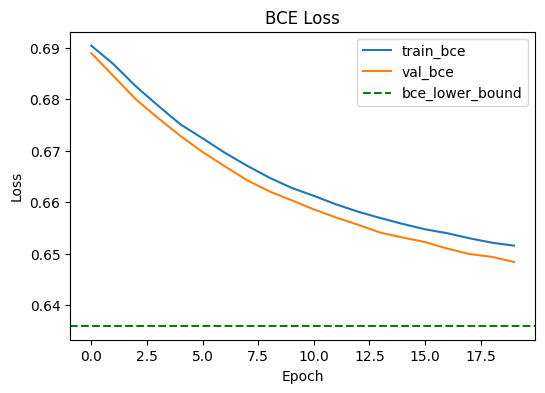

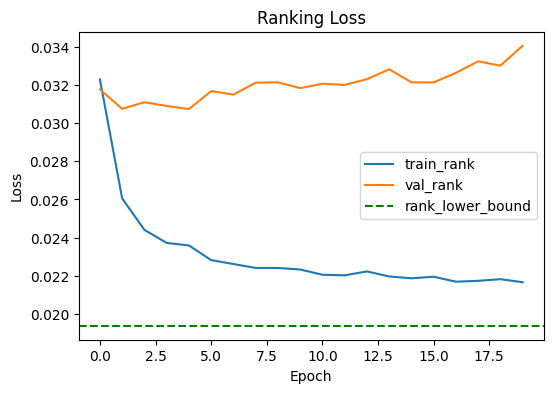

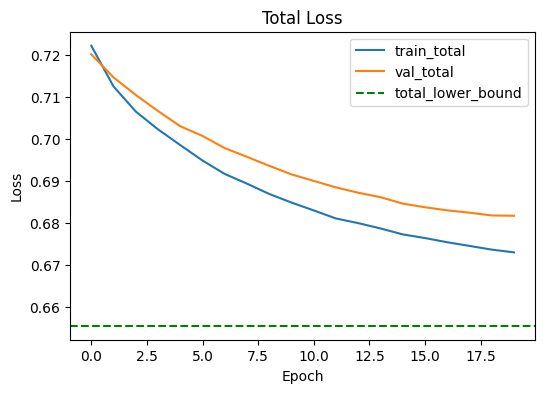

In [11]:
import matplotlib.pyplot as plt

# ===== BCE =====
train_bce = [x["bce"] for x in best_clf.train_losses]
val_bce = [x["bce"] for x in best_clf.val_losses]

plt.figure(figsize=(6, 4))
plt.plot(train_bce, label="train_bce")
plt.plot(val_bce, label="val_bce")

plt.axhline(
    lower_val["bce_lower_bound"],
    linestyle="--",
    color="green",
    label="bce_lower_bound"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BCE Loss")
plt.legend()
plt.show()


# ===== RANK =====
train_rank = [x["rank"] for x in best_clf.train_losses]
val_rank = [x["rank"] for x in best_clf.val_losses]

plt.figure(figsize=(6, 4))
plt.plot(train_rank, label="train_rank")
plt.plot(val_rank, label="val_rank")

plt.axhline(
    lower_val["rank_lower_bound"],
    linestyle="--",
    color="green",
    label="rank_lower_bound"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Ranking Loss")
plt.legend()
plt.show()


# ===== TOTAL =====
train_total = [x["loss"] for x in best_clf.train_losses]
val_total = [x["loss"] for x in best_clf.val_losses]

plt.figure(figsize=(6, 4))
plt.plot(train_total, label="train_total")
plt.plot(val_total, label="val_total")

plt.axhline(
    lower_val["total_lower_bound"],
    linestyle="--",
    color="green",
    label="total_lower_bound"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Total Loss")
plt.legend()
plt.show()

In [12]:
import numpy as np
import pandas as pd

from mhdr.classifier.postprocess import scores_to_ranked_vector_threshold_top1

test_items = [
    ("TEST_1", "I feel disconnected from my friends."),
    ("TEST_2", "I feel overwhelmed by my emotions."),
    ("TEST_3", "My body feels tired and drained."),
    ("TEST_4", "I worry about my financial future."),
    ("TEST_5", "I enjoy challenging my mind with new ideas."),
    ("TEST_6", "My life feels connected to a deeper purpose."),
    ("TEST_7", "My living environment makes me uncomfortable."),
    ("TEST_8", "I am able to adapt when changes occur"),
]

rows = []

best_threshold = float(best_post["threshold"])

for qid, text in test_items:

    scores = best_clf.predict_scores([text])[0]
    probs = 1 / (1 + np.exp(-scores))

    pred = scores_to_ranked_vector_threshold_top1(
        scores=scores,
        dimensions=DIMENSIONS,
        threshold=best_threshold,
    )

    row = {
        "qid": qid,
        "text": text,
    }

    # raw scores
    for d, s in zip(DIMENSIONS, scores):
        row[f"{d}_score"] = float(s)

    # probabilities
    for d, p in zip(DIMENSIONS, probs):
        row[f"{d}_prob"] = float(p)

    # predicted rank
    for d in DIMENSIONS:
        row[d] = pred[d]

    rows.append(row)

pred_df = pd.DataFrame(rows)

print(pred_df)
for qid, text in test_items:
    scores = best_clf.predict_scores([text])[0]
    order = np.argsort(scores)[::-1]
    print(qid, text)
    print([(DIMENSIONS[i], float(scores[i])) for i in order[:3]])
    print()

      qid                                           text  Emotional_score  \
0  TEST_1           I feel disconnected from my friends.        -0.417182   
1  TEST_2             I feel overwhelmed by my emotions.        -0.501168   
2  TEST_3               My body feels tired and drained.        -0.287098   
3  TEST_4             I worry about my financial future.        -0.391624   
4  TEST_5    I enjoy challenging my mind with new ideas.        -0.397746   
5  TEST_6   My life feels connected to a deeper purpose.        -0.479834   
6  TEST_7  My living environment makes me uncomfortable.        -0.397485   
7  TEST_8          I am able to adapt when changes occur        -0.274953   

   Environmental_score  Financial_score  Intellectual_score  \
0            -0.373744        -0.562392           -0.471464   
1            -0.476418        -0.496302           -0.478621   
2            -0.297623        -0.347473           -0.343563   
3            -0.348229        -0.359804           -0.3

In [13]:
import numpy as np
import pandas as pd

from mhdr.classifier.postprocess import scores_to_ranked_vector_threshold_top1

test_items = [
    ("TEST_1", "I feel disconnected from my friends."),
    ("TEST_2", "I feel overwhelmed by my emotions."),
    ("TEST_3", "My body feels tired and drained."),
    ("TEST_4", "I worry about my financial future."),
    ("TEST_5", "I enjoy challenging my mind with new ideas."),
    ("TEST_6", "My life feels connected to a deeper purpose."),
    ("TEST_7", "My living environment makes me uncomfortable."),
    ("TEST_8", "I am able to adapt when changes occur"),
]

rows = []

best_threshold = float(best_post["threshold"])

for qid, text in test_items:
    scores = best_clf.predict_scores([text])[0]

    row = {
        "qid": qid,
        "text": text,
    }

    row.update(
        scores_to_ranked_vector_threshold_top1(
            scores=scores,
            dimensions=DIMENSIONS,
            threshold=best_threshold,
        )
    )

    rows.append(row)

pred_df = pd.DataFrame(rows)
pred_df = pred_df[["qid", "text"] + DIMENSIONS]

print(pred_df)

      qid                                           text  Emotional  \
0  TEST_1           I feel disconnected from my friends.          0   
1  TEST_2             I feel overwhelmed by my emotions.          0   
2  TEST_3               My body feels tired and drained.          1   
3  TEST_4             I worry about my financial future.          0   
4  TEST_5    I enjoy challenging my mind with new ideas.          0   
5  TEST_6   My life feels connected to a deeper purpose.          0   
6  TEST_7  My living environment makes me uncomfortable.          0   
7  TEST_8          I am able to adapt when changes occur          0   

   Environmental  Financial  Intellectual  Occupational  Physical  Social  \
0              1          0             0             0         0       0   
1              1          0             0             0         0       0   
2              0          0             0             0         0       0   
3              0          0             0           